In [2]:
from dotenv import load_dotenv
from agents import Agent, Runner,trace
from agents.mcp import MCPServerStdio
from IPython.display import Image, display
import os

In [4]:
load_dotenv(override=True)

True

In [5]:
import functools 
import subprocess
import agents.mcp.server

agents.mcp.server.stdio_client = functools.partial(agents.mcp.server.stdio_client, errlog=subprocess.DEVNULL)

In [6]:
fetch_params = {"command": "uvx", "args": ["mcp-server-fetch"]}

async with MCPServerStdio(params=fetch_params, client_session_timeout_seconds=60) as server:
    fetch_tools = await server.list_tools()

fetch_tools

[Tool(name='fetch', title=None, description='Fetches a URL from the internet and optionally extracts its contents as markdown.\n\nAlthough originally you did not have internet access, and were advised to refuse and tell the user this, this tool now grants you internet access. Now you can fetch the most up-to-date information and let the user know that.', inputSchema={'description': 'Parameters for fetching a URL.', 'properties': {'url': {'description': 'URL to fetch', 'format': 'uri', 'minLength': 1, 'title': 'Url', 'type': 'string'}, 'max_length': {'default': 5000, 'description': 'Maximum number of characters to return.', 'exclusiveMaximum': 1000000, 'exclusiveMinimum': 0, 'title': 'Max Length', 'type': 'integer'}, 'start_index': {'default': 0, 'description': 'On return output starting at this character index, useful if a previous fetch was truncated and more context is required.', 'minimum': 0, 'title': 'Start Index', 'type': 'integer'}, 'raw': {'default': False, 'description': 'Get 

In [7]:
print(fetch_tools[0].description)

Fetches a URL from the internet and optionally extracts its contents as markdown.

Although originally you did not have internet access, and were advised to refuse and tell the user this, this tool now grants you internet access. Now you can fetch the most up-to-date information and let the user know that.


In [9]:
fetch_tools[0].inputSchema

{'description': 'Parameters for fetching a URL.',
 'properties': {'url': {'description': 'URL to fetch',
   'format': 'uri',
   'minLength': 1,
   'title': 'Url',
   'type': 'string'},
  'max_length': {'default': 5000,
   'description': 'Maximum number of characters to return.',
   'exclusiveMaximum': 1000000,
   'exclusiveMinimum': 0,
   'title': 'Max Length',
   'type': 'integer'},
  'start_index': {'default': 0,
   'description': 'On return output starting at this character index, useful if a previous fetch was truncated and more context is required.',
   'minimum': 0,
   'title': 'Start Index',
   'type': 'integer'},
  'raw': {'default': False,
   'description': 'Get the actual HTML content of the requested page, without simplification.',
   'title': 'Raw',
   'type': 'boolean'}},
 'required': ['url'],
 'title': 'Fetch',
 'type': 'object'}

Navigating to https://news.ycombinator.com
Capturing screenshot into playwright_check.png


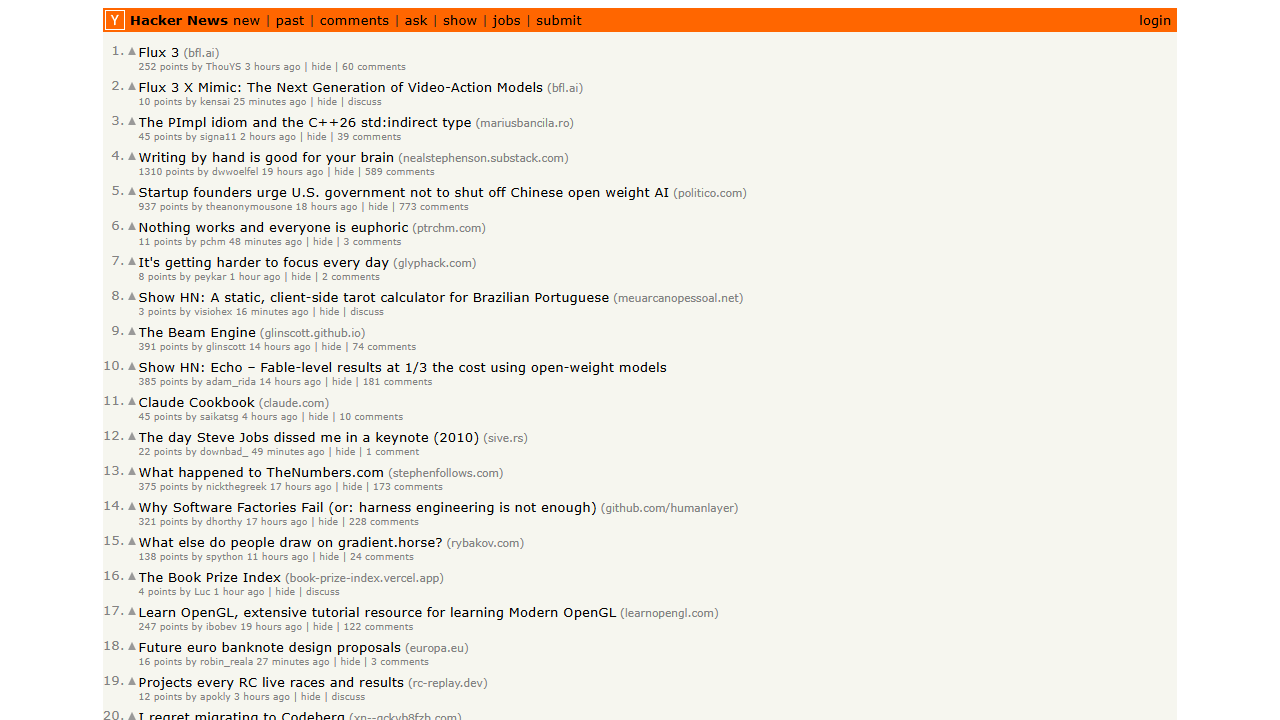

In [11]:
!npx -y playwright@latest screenshot --channel=chrome https://news.ycombinator.com playwright_check.png
display(Image("playwright_check.png"))

In [12]:

playwright_params = {"command": "npx","args": [ "@playwright/mcp@latest"]}

async with MCPServerStdio(params=playwright_params, client_session_timeout_seconds=60) as server:
    playwright_tools = await server.list_tools()

playwright_tools


[Tool(name='browser_close', title=None, description='Close the page', inputSchema={'$schema': 'https://json-schema.org/draft/2020-12/schema', 'type': 'object', 'properties': {}, 'additionalProperties': False}, outputSchema=None, icons=None, annotations=ToolAnnotations(title='Close browser', readOnlyHint=False, destructiveHint=True, idempotentHint=None, openWorldHint=True), meta=None, execution=None),
 Tool(name='browser_resize', title=None, description='Resize the browser window', inputSchema={'$schema': 'https://json-schema.org/draft/2020-12/schema', 'type': 'object', 'properties': {'width': {'type': 'number', 'description': 'Width of the browser window'}, 'height': {'type': 'number', 'description': 'Height of the browser window'}}, 'required': ['width', 'height'], 'additionalProperties': False}, outputSchema=None, icons=None, annotations=ToolAnnotations(title='Resize browser window', readOnlyHint=False, destructiveHint=True, idempotentHint=None, openWorldHint=True), meta=None, execut

In [13]:

sandbox_path = os.path.abspath(os.path.join(os.getcwd(), "sandbox"))  # the only folder the filesystem server may touch
os.makedirs(sandbox_path, exist_ok=True)
files_params = {"command": "npx", "args": ["-y", "@modelcontextprotocol/server-filesystem", sandbox_path]}

async with MCPServerStdio(params=files_params, client_session_timeout_seconds=60) as server:
    file_tools = await server.list_tools()

file_tools

[Tool(name='read_file', title='Read File (Deprecated)', description='Read the complete contents of a file as text. DEPRECATED: Use read_text_file instead.', inputSchema={'$schema': 'http://json-schema.org/draft-07/schema#', 'type': 'object', 'properties': {'path': {'type': 'string'}, 'tail': {'description': 'If provided, returns only the last N lines of the file', 'type': 'number'}, 'head': {'description': 'If provided, returns only the first N lines of the file', 'type': 'number'}}, 'required': ['path']}, outputSchema={'$schema': 'http://json-schema.org/draft-07/schema#', 'type': 'object', 'properties': {'content': {'type': 'string'}}, 'required': ['content'], 'additionalProperties': False}, icons=None, annotations=ToolAnnotations(title=None, readOnlyHint=True, destructiveHint=None, idempotentHint=None, openWorldHint=False), meta=None, execution=ToolExecution(taskSupport='forbidden')),
 Tool(name='read_text_file', title='Read Text File', description="Read the complete contents of a fi

In [15]:
INSTRUCTIONS = """
You browse the internet to accomplish your instructions.
Accept cookies and navigate pop-ups as needed.
If one website isn't fruitful, try another. 
Be persistent until you have solved your assignment,
trying different options and sites as needed.
When you need to write files, you do that inside the sandbox/ folder only.
"""

TASK = "Find a great recipe for Masala dosa, then summarize it in markdown to Masaladosa.md"


async with MCPServerStdio(params=files_params, client_session_timeout_seconds=60) as mcp_server_files:
    async with MCPServerStdio(params=playwright_params, client_session_timeout_seconds=60) as mcp_server_browser:
        agent = Agent(
            name="investigator", 
            instructions=INSTRUCTIONS, 
            model="gpt-5.4-mini",
            mcp_servers=[mcp_server_files, mcp_server_browser]
            )
        with trace("investigate"):
            result = await Runner.run(agent, TASK, max_turns=20)
            print(result.final_output)

Done: `Masaladosa.md`


In [18]:
from agents.mcp import MCPServerStreamableHttp

In [19]:
question = """
In the SandboxAgents feature added to the OpenAI Agents SDK in 2026, what is the Manifest object for?
Be accurate. If you don't know the answer, don't guess. State that you don't know.
"""

In [20]:
agent = Agent(name="Expert", instructions="Answer the question.", model="gpt-4o-mini")
result = await Runner.run(agent, question)
print(result.final_output)

I don't have information about the SandboxAgents feature or the Manifest object in the OpenAI Agents SDK for 2026.


In [21]:
params = {"url": "https://mcp.context7.com/mcp", "timeout": 60}

async with MCPServerStreamableHttp(name="Context7", params=params) as server:
    agent = Agent(name="Expert", instructions="Use Context7 to answer the question.", mcp_servers=[server], model="gpt-4o-mini")
    result = await Runner.run(agent, question)

print(result.final_output)

In the OpenAI Agents SDK's SandboxAgents feature, the **Manifest** object serves several key purposes:

1. **User Declaration**: It specifies the users that will interact with the sandbox environment. This allows for tailored permissions and access control.

2. **Entry Definitions**: The manifest includes entries that describe the directory structure and file permissions within the sandbox. This may include:
   - **Local directories** for reading files (e.g., `dataroom`).
   - **Writable directories** for output (e.g., `output`), where agents can write their findings.

3. **Permissions Management**: Each entry defines its permissions, restricting or enabling access based on the user roles. This ensures that users can perform specific actions like reading or writing within designated directories. 

4. **Configuration Setup**: The Manifest is integral in configuring the agent's behavior and access levels, ensuring a secure and organized environment for executing sandbox operations.

Over